# Import Dependencies

Pada tahap ini dilakukan instalasi pustaka (*library*) yang diperlukan untuk menjalankan proses analisis dan pemodelan **Natural Language Processing (NLP)**. Library `gensim` digunakan untuk membangun model **Word2Vec**, yaitu metode *word embedding* yang merepresentasikan kata dalam bentuk vektor numerik sehingga dapat menangkap hubungan semantik antar kata. Selain itu, library `scikit-optimize` digunakan untuk melakukan optimasi hiperparameter model melalui pendekatan *Bayesian Optimization*.

In [ ]:
!pip install gensim scikit-optimize

Nilai *random seed* ditetapkan untuk memastikan proses eksperimen bersifat ***reproducible***, sehingga hasil pelatihan model dapat direproduksi kembali ketika kode dijalankan ulang. Parameter `VECTOR_SIZE` digunakan untuk menentukan dimensi vektor pada model **Word2Vec**.

In [ ]:
SEED = 1010
VECTOR_SIZE = 100

In [ ]:
import joblib
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import tensorflow as tf
from gensim.models import Word2Vec
from lightgbm import LGBMClassifier
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from umap import UMAP

# custom module
from utils import model_eval, plot_history, sentence_vector

nltk.download("punkt_tab")

tf.random.set_seed(SEED)
np.random.seed(SEED)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Data

Dataset dimuat menggunakan fungsi `read_csv()` dari pustaka `pandas`. Dari dataset yang tersedia, hanya dua kolom yang digunakan dalam penelitian ini, yaitu kolom `content` yang berisi teks ulasan pengguna dan kolom `sentiment` yang berisi label sentimen.

In [ ]:
# Memuat dataset
df = pd.read_csv("clean_review_bsi_mobile.csv")
df = df[['content', 'sentiment']]
df.sample(10, random_state=SEED)

,content,sentiment
6393,transaksi susah ribet transfer orangkirain gag...,negative
823,top up dana gk,negative
12199,force close melulu qr eror mlu deh,negative
2259,paksa ganti akses uang situ suruh ganti pakai ...,negative
3632,mudah guna,positive
9423,apknya ui banget pakai syariah capek banget ba...,negative
13536,pakai kendalasemua bagus profil layan pinjaman...,positive
8017,baru deteksi device rooted device gx rooted al...,negative
13047,ganggu,negative
3501,buka habis,negative


In [ ]:
# Tampilkan informasi umum tentang dataset
print("\nInformasi dataset:")
df.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13969 entries, 0 to 13968
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    13963 non-null  object
 1   sentiment  13969 non-null  object
dtypes: object(2)
memory usage: 218.4+ KB


Berdasarkan informasi dataset, terdapat **13.969 baris data** dengan dua atribut utama, yaitu teks ulasan (`content`) dan label sentimen (`sentiment`).

In [ ]:
# Cek missing values
print("\nMissing values per fitur:")
print(df.isnull().sum())


Missing values per fitur:
content      6
sentiment    0
dtype: int64


Selanjutnya dilakukan pemeriksaan terhadap *missing values* pada setiap fitur. Hasil pemeriksaan menunjukkan terdapat **6 nilai kosong pada kolom `content`**. Data yang memiliki nilai kosong kemudian dihapus menggunakan metode `dropna()` untuk menjaga kualitas data yang digunakan dalam proses pelatihan model.

In [ ]:
# Menghapus baris dengan missing values
df.dropna(inplace=True)

print("\nInformasi dataset setelah penanganan missing values:")
df.info()


Informasi dataset setelah penanganan missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 13963 entries, 0 to 13968
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   content    13963 non-null  object
 1   sentiment  13963 non-null  object
dtypes: object(2)
memory usage: 327.3+ KB


Setelah proses penanganan *missing values*, jumlah data yang tersisa adalah **13.963 baris** yang selanjutnya digunakan dalam proses pemodelan.

# Data Splitting

In [ ]:
# Memisahkan fitur dengan label
X = df['content']
y = df['sentiment']

In [ ]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11170,), (2793,), (11170,), (2793,))

Data kemudian dibagi menjadi data latih dan data uji menggunakan teknik *stratified train-test split* berdasarkan label `sentiment` dengan proporsi **80% data latih dan 20% data uji**. Pendekatan ini digunakan untuk memastikan distribusi kelas sentimen pada data latih dan data uji tetap seimbang dengan distribusi pada dataset asli.

# Feature Extraction

## Tokenization

Pada tahap ini dilakukan **tokenisasi** terhadap teks pada kolom `content` menggunakan fungsi `word_tokenize()` dari pustaka `nltk`. Proses tokenisasi bertujuan untuk memecah teks ulasan menjadi unit kata (*tokens*) sehingga dapat diproses oleh model Word2Vec dalam tahap pembelajaran representasi kata.

In [ ]:
# Melakukan tokenisasi terhadap kolom `content`
X_train, X_test = X_train.apply(word_tokenize), X_test.apply(word_tokenize)

X_train.sample(10, random_state=SEED)

,content
6798,"[keren, mudahlebih, efektif, moga, amanah]"
8352,[mantap]
7365,"[baik, sistem, operasi, qris, scan, qr, susah,..."
10664,[kecewa]
3197,[bagus]
2726,"[alhamdulillah, aman, percaya, pakai, benar, b..."
11567,"[online, mudah, lha, susah, akses, habis, teru..."
9625,"[iya, verifikasi, aktifasi, gagal]"
5133,"[terkadang, lambat, konek, iya]"
9840,"[iya, transfer, force, close]"


## Word2Vec

Setelah proses tokenisasi, dilakukan pelatihan model **Word2Vec** untuk menghasilkan representasi vektor dari setiap kata. Model Word2Vec mempelajari hubungan semantik antar kata berdasarkan konteks kemunculannya dalam kalimat.

Pada penelitian ini digunakan beberapa parameter utama, yaitu:

* `vector_size = 100` untuk menentukan dimensi vektor kata

* `window = 10` untuk menentukan jumlah kata konteks yang diperhatikan di sekitar kata target

* `min_count = 5` untuk mengabaikan kata yang muncul kurang dari 5 kali

* `epochs = 100` untuk jumlah iterasi pelatihan model

In [ ]:
# Melatih model Word2Vec untuk mempelajari representasi vektor kata
embed_model = Word2Vec(
    sentences=X_train,
    vector_size=VECTOR_SIZE,
    window=10,
    min_count=5,
    workers=4,
    epochs=100,
    seed=SEED
)

Setelah model Word2Vec dilatih, langkah selanjutnya adalah melakukan **ekstraksi fitur kalimat**. Setiap kalimat direpresentasikan dalam bentuk vektor dengan cara menggabungkan vektor kata yang terdapat dalam kalimat tersebut menggunakan fungsi `sentence_vector()`.

Hasil proses ini adalah matriks fitur numerik yang merepresentasikan setiap ulasan pengguna dalam bentuk vektor berdimensi tetap, sehingga dapat digunakan sebagai input untuk model klasifikasi.

In [ ]:
X_train_vec = np.array([sentence_vector(tokens, embed_model) for tokens in X_train])
X_test_vec = np.array([sentence_vector(tokens, embed_model) for tokens in X_test])

X_train_vec.shape, X_test_vec.shape

((11170, 100), (2793, 100))

### Sanity Check by Similar Words

Fungsi `similar_by_word()` digunakan untuk mengevaluasi kualitas embedding dengan melihat kata-kata yang memiliki nilai cosine similarity tertinggi terhadap kata tertentu. Jika model Word2Vec berhasil mempelajari hubungan semantik dari korpus, maka kata-kata yang muncul sebagai hasil kemiripan akan memiliki konteks penggunaan yang serupa dengan kata yang diuji.

In [ ]:
embed_model.wv.similar_by_word("bug", topn=5)

[('stuck', 0.2870144248008728),
 ('hang', 0.2770722806453705),
 ('adzan', 0.2553107738494873),
 ('putih', 0.2525300085544586),
 ('simpan', 0.24519413709640503)]

### Sanity Check by High Order Visualization

Vektor hasil pelatihan Word2Vec memiliki dimensi tinggi (dalam contoh ini 100 dimensi) sehingga sulit untuk divisualisasikan secara langsung. Oleh karena itu digunakan metode reduksi dimensi **UMAP (Uniform Manifold Approximation and Projection)** untuk memproyeksikan representasi vektor kata ke dalam ruang dua dimensi sehingga hubungan antar kata dapat divisualisasikan.

Visualisasi ini membantu melihat apakah kata-kata dengan konteks yang serupa cenderung membentuk cluster yang berdekatan dalam ruang vektor.

In [ ]:
# Melakukan reduksi dimensi word embedding menggunakan UMAP
umap_embeddings = UMAP().fit_transform(embed_model.wv.vectors)

# Membuat dataframe untuk menyimpan hasil proyeksi UMAP
# serta kata yang bersesuaian dengan setiap vektor embedding
df_umap = pd.DataFrame(umap_embeddings, columns=["umap1", "umap2"])
df_umap["word"] = embed_model.wv.index_to_key
df_umap.sample(10, random_state=SEED)

,umap1,umap2,word
1239,6.416432,12.667789,nyaaa
444,6.797758,10.427066,nyoba
834,4.811627,14.657681,kerenn
566,5.712080,12.598549,woi
1177,4.251338,12.491561,nonaktif
1199,4.396407,14.333005,insyaallah
1229,2.378477,11.894135,walet
267,4.413613,12.401642,banyak
908,5.890634,9.908074,donlod
82,3.580639,13.329196,laku


In [ ]:
# Memvisualisasikan hubungan antar kata dalam ruang 2 dimensi
fig = px.scatter(df_umap, x="umap1", y="umap2", text="word")
fig.update_traces(textposition="top center")
fig.update_layout(
    height=800,
    title_text="Reduced Word2Vec Visualization"
)
fig.show()

Dari visualisasi hasil reduksi dimensi menggunakan UMAP terlihat bahwa beberapa kata dengan konteks yang serupa cenderung berada pada area yang berdekatan. Hal ini mengindikasikan bahwa model Word2Vec telah berhasil menangkap sebagian hubungan semantik antar kata dalam korpus. Namun demikian, visualisasi ini hanya memberikan indikasi awal dan belum cukup untuk menyimpulkan kualitas embedding secara menyeluruh.

# Standardization

Karena beberapa algoritma yang digunakan, seperti Support Vector Machine dan Artificial Neural Network, sensitif terhadap skala fitur, maka dilakukan standardisasi menggunakan `StandardScaler` agar setiap fitur memiliki distribusi dengan mean 0 dan standar deviasi 1. Hal ini membantu proses optimasi model menjadi lebih stabil.

In [ ]:
standard_scaler = StandardScaler()
X_train_vec = standard_scaler.fit_transform(X_train_vec)

# Label Encoding

Label sentimen yang bersifat kategorikal (`negative`, `neutral`, `positive`) diubah menjadi representasi numerik menggunakan `LabelEncoder` agar dapat digunakan oleh algoritma machine learning.

In [ ]:
# Encoding label sentimen mejadi representasi numerik
sentiment_encoder = LabelEncoder()

y_train_enc, y_test_enc = sentiment_encoder.fit_transform(y_train), sentiment_encoder.transform(y_test)

# Modelling

Akan dicobakan tiga algoritma:
* Artificial Neural Network (ANN)
* LightGBM (LGBM)
* Support Vector Machine (SVM)

# Artificial Neural Network

### Training Preparation

In [ ]:
# Inisialisasi arsitektur Artificial Neural Network
ann_model = Sequential(
    [
        Input(shape=(VECTOR_SIZE,)),
        Dense(16, activation="relu", kernel_initializer="he_normal"),
        BatchNormalization(momentum=0.9),
        Dropout(0.3),
        Dense(16, activation="relu", kernel_initializer="he_normal"),
        BatchNormalization(momentum=0.9),
        Dropout(0.3),
        Dense(3, activation="softmax"),
    ]
)
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001)
criterion = tf.keras.losses.SparseCategoricalCrossentropy()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [ ]:
ann_model.compile(
    optimizer=optimizer,
    loss=criterion,
    metrics=['accuracy']
)

### Train Model

In [ ]:
history = ann_model.fit(
    X_train_vec, y_train_enc,
    validation_split=0.2,
    epochs=10_000,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4249 - loss: 1.3305 - val_accuracy: 0.8554 - val_loss: 0.5142
Epoch 2/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7345 - loss: 0.6859 - val_accuracy: 0.9167 - val_loss: 0.3226
Epoch 3/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8498 - loss: 0.4590 - val_accuracy: 0.9288 - val_loss: 0.2625
Epoch 4/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8864 - loss: 0.3835 - val_accuracy: 0.9315 - val_loss: 0.2376
Epoch 5/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9006 - loss: 0.3457 - val_accuracy: 0.9338 - val_loss: 0.2276
Epoch 6/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9070 - loss: 0.3182 - val_accuracy: 0.9351 - val_loss: 0.2208
Epoch 7/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9138 - loss: 0.3088 - val_accuracy: 0.9355 - val_loss: 0.2174
Epoch 8/10000
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9152 - loss: 0.3018 - 

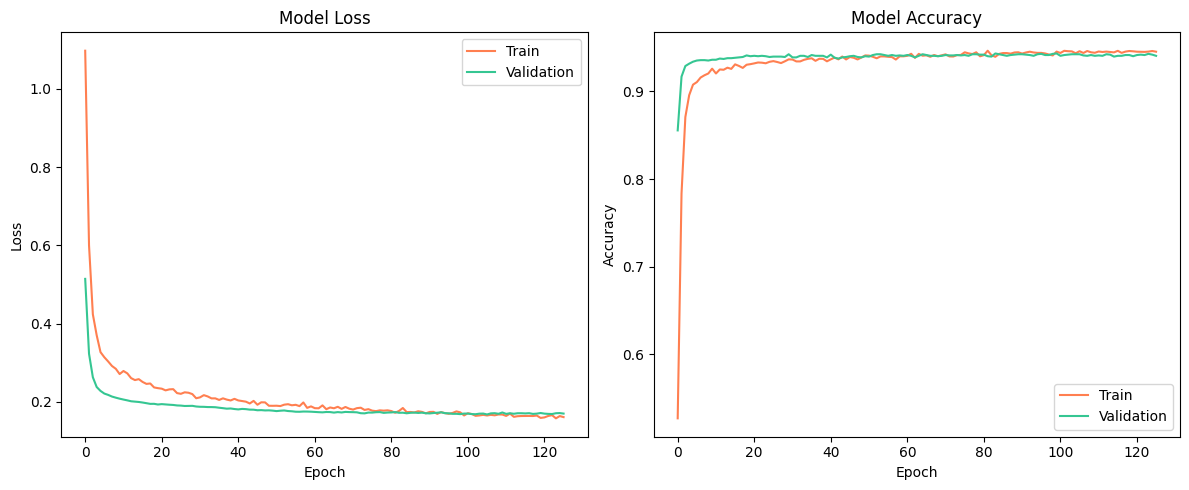

In [ ]:
plot_history(history)

Dari grafik training loss dan validation loss terlihat bahwa model telah mencapai kondisi konvergen. Selain itu, perbedaan antara training dan validation metrics relatif kecil sehingga tidak terlihat indikasi overfitting yang signifikan.

### Model Evaluation

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


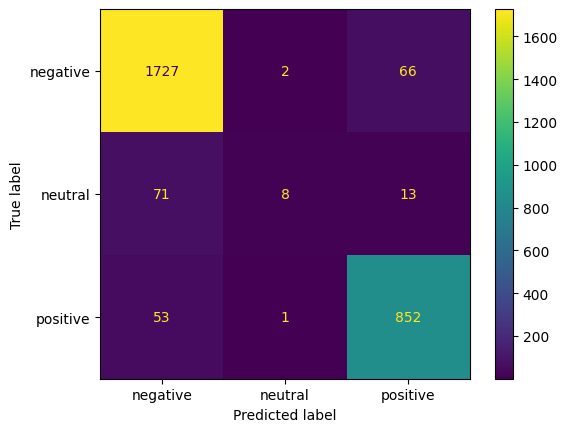

In [ ]:
ann_metrics_df = model_eval(ann_model, X_test_vec, y_test_enc, standard_scaler, sentiment_encoder)

Berdasarkan confusion matrix, model mampu memprediksi kelas `negative` dan `positive` dengan cukup baik. Hal ini terlihat dari jumlah prediksi benar yang relatif tinggi pada kedua kelas tersebut.

Namun, performa model pada kelas `neutral` masih cukup rendah. Sebagian besar data berlabel `neutral` diprediksi sebagai `negative`. Hal ini menunjukkan bahwa model mengalami kesulitan dalam membedakan pola fitur antara kelas `neutral` dan `negative`.

Salah satu kemungkinan penyebabnya adalah ketidakseimbangan distribusi data antar kelas, di mana jumlah data neutral jauh lebih sedikit dibandingkan dengan kelas lainnya. Kondisi ini menyebabkan model kurang mampu mempelajari karakteristik dari kelas `neutral`.

In [ ]:
ann_metrics_df

,Accuracy,Precision,Recall,F1 Score
0,0.926244,0.920438,0.926244,0.67676


Meskipun nilai accuracy cukup tinggi, nilai F1-macro relatif lebih rendah. Hal ini menunjukkan bahwa performa model tidak merata pada semua kelas, khususnya pada kelas `neutral` yang memiliki jumlah data lebih sedikit.

##  Light Gradient-Boosting Machine

### Train Model

In [ ]:
params = {
    "boosting_type": Categorical(["gbdt", "dart"], prior=None),
    "num_leaves": Integer(20, 150),
    "max_depth": Integer(3, 12),
    "learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "min_child_samples": Integer(5, 100),
    "min_child_weight": Real(1e-3, 10, prior="log-uniform"),
    "subsample": Real(0.5, 1.0, prior="uniform"),
    "colsample_bytree": Real(0.5, 1.0, prior="uniform"),
    "reg_alpha": Real(1e-9, 100.0, prior="log-uniform"),
    "reg_lambda": Real(1e-9, 100.0, prior="log-uniform"),
    "min_split_gain": Real(0.0, 1.0),
    "max_bin": Integer(100, 500)
}

# Inisialisasi Bayesian Search
lgb_model = BayesSearchCV(
    estimator=LGBMClassifier(objective="multiclass", num_class=3, n_jobs=-1, random_state=SEED),
    search_spaces=params,
    cv=5,
    scoring="f1_macro",
    n_iter=100,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
)
lgb_model.fit(X_train_vec, y_train_enc)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

BayesSearchCV(cv=5,
              estimator=LGBMClassifier(n_jobs=-1, num_class=3,
                                       objective='multiclass',
                                       random_state=1010),
              n_iter=100, n_jobs=-1, random_state=1010, scoring='f1_macro',
              search_spaces={'boosting_type': Categorical(categories=('gbdt', 'dart'), prior=None),
                             'colsample_bytree': Real(low=0.5, high=1.0, prior='uniform', transform='normalize'),
                             'learning_rate': Real(l...
                             'min_split_gain': Real(low=0.0, high=1.0, prior='uniform', transform='normalize'),
                             'num_leaves': Integer(low=20, high=150, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=1e-09, high=100.0, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=1e-09, high=100.0, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')},
              verbose=1)

In [ ]:
# Menampilkan hyperparameter terbaik dari Bayesian Search
print("Best parameters:", lgb_model.best_params_)
print("Best CV Score:", lgb_model.best_score_)
print("Test Score:", lgb_model.score(X_test_vec, y_test_enc))

Best parameters: OrderedDict({'boosting_type': 'gbdt', 'colsample_bytree': 0.6375450736620186, 'learning_rate': 0.25877784516197666, 'max_bin': 100, 'max_depth': 3, 'min_child_samples': 8, 'min_child_weight': 1.5661192775366242, 'min_split_gain': 0.7561023189889877, 'num_leaves': 46, 'reg_alpha': 3.2626149876340445e-09, 'reg_lambda': 1e-09, 'subsample': 0.6405543299207921})
Best CV Score: 0.7160822096806195
Test Score: 0.6417903884873842


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



Terlihat adanya indikasi overfitting ringan karena nilai F1-macro pada data validasi cross-validation (71.6%) lebih tinggi dibandingkan performa pada data test (64.2%).

### Model Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



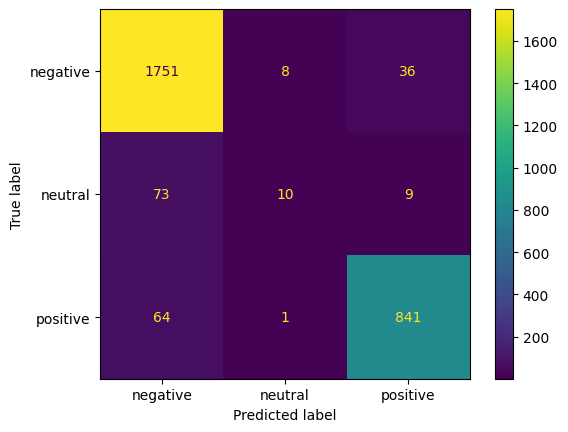

In [ ]:
lgb_metrics_df = model_eval(lgb_model, X_test_vec, y_test_enc, standard_scaler, sentiment_encoder)

Berdasarkan confusion matrix, model mampu memprediksi kelas `negative` dan `positive` dengan cukup baik. Hal ini terlihat dari jumlah prediksi benar yang relatif tinggi pada kedua kelas tersebut.

Namun, performa model pada kelas `neutral` masih cukup rendah. Sebagian besar data berlabel `neutral` diprediksi sebagai `negative`. Hal ini menunjukkan bahwa model mengalami kesulitan dalam membedakan pola fitur antara kelas `neutral` dan `negative`.

Salah satu kemungkinan penyebabnya adalah ketidakseimbangan distribusi data antar kelas, di mana jumlah data neutral jauh lebih sedikit dibandingkan dengan kelas lainnya. Kondisi ini menyebabkan model kurang mampu mempelajari karakteristik dari kelas `neutral`.

In [ ]:
lgb_metrics_df

,Accuracy,Precision,Recall,F1 Score
0,0.931615,0.921287,0.931615,0.689884


Model LGBM berhasil mendapatkan 93.2% accuracy, 92.1% Weighted Precision, 93.2% Weighted Recall, dan 69.0% F1-macro pada data test.

## Support Vector Machine

In [ ]:
params = {
    "kernel": Categorical(["linear", "poly", "rbf", "sigmoid"], prior=None),
    "gamma": Real(low=1e-3, high=1e3, prior="log-uniform", transform="identity"),
    "C": Real(low=1e-3, high=1e3, prior="log-uniform", transform="identity"),
    "degree": Categorical([2, 3], prior=None)
}

# Inisialisasi Bayesian Search
svc_model = BayesSearchCV(
    estimator=SVC(max_iter=500, random_state=42),
    search_spaces=params,
    cv=5,
    scoring="f1_macro",
    n_iter=100,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
)
svc_model.fit(X_train_vec, y_train_enc)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning:

Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.



BayesSearchCV(cv=5, estimator=SVC(max_iter=500, random_state=42), n_iter=100,
              n_jobs=-1, random_state=1010, scoring='f1_macro',
              search_spaces={'C': Real(low=0.001, high=1000.0, prior='log-uniform', transform='normalize'),
                             'degree': Categorical(categories=(2, 3), prior=None),
                             'gamma': Real(low=0.001, high=1000.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('linear', 'poly', 'rbf', 'sigmoid'), prior=None)},
              verbose=1)

In [ ]:
# Menampilkan hyperparameter terbaik dari Bayesian Search
print("Best parameters:", svc_model.best_params_)
print("Best CV Score:", svc_model.best_score_)
print("Test Score:", svc_model.score(X_test_vec, y_test_enc))

Best parameters: OrderedDict({'C': 38.77017395035284, 'degree': 2, 'gamma': 0.005421651682068213, 'kernel': 'rbf'})
Best CV Score: 0.7151374558070226
Test Score: 0.6564037944470571


Terindikasi ada cukup overfitting karena Best CV Score 71.5%, sedangkan test score 65.6%.

## Model Evaluation

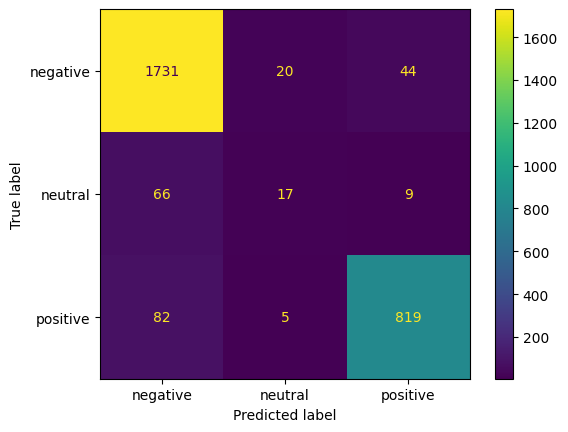

In [ ]:
svc_metrics_df = model_eval(svc_model, X_test_vec, y_test_enc, standard_scaler, sentiment_encoder)

Berdasarkan confusion matrix, model mampu memprediksi kelas `negative` dan `positive` dengan cukup baik. Hal ini terlihat dari jumlah prediksi benar yang relatif tinggi pada kedua kelas tersebut.

Namun, performa model pada kelas `neutral` masih cukup rendah. Sebagian besar data berlabel `neutral` diprediksi sebagai `negative`. Hal ini menunjukkan bahwa model mengalami kesulitan dalam membedakan pola fitur antara kelas `neutral` dan `negative`.

Salah satu kemungkinan penyebabnya adalah ketidakseimbangan distribusi data antar kelas, di mana jumlah data neutral jauh lebih sedikit dibandingkan dengan kelas lainnya. Kondisi ini menyebabkan model kurang mampu mempelajari karakteristik dari kelas `neutral`.

In [ ]:
svc_metrics_df

,Accuracy,Precision,Recall,F1 Score
0,0.919083,0.910057,0.919083,0.705763


Model SVM berhasil mendapatkan 91.9% accuracy, 91.0% Weighted Precision, 91.9% Weighted Recall, dan 70.6% F1-macro pada data test.

# Conclusion

In [ ]:
# Menggabungkan metrik evaluasi dari ketiga model
metrics = {
    "ANN": ann_metrics_df,
    "LGBM": lgb_metrics_df,
    "SVC": svc_metrics_df
}

# Menggabungkan dataframe metrik menjadi satu tabel
metrics_df = pd.concat(metrics)
metrics_df.index = metrics_df.index.droplevel(1)
metrics_df.index.name = "Model"
metrics_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
ANN,0.926244,0.920438,0.926244,0.676760
LGBM,0.931615,0.921287,0.931615,0.689884
SVC,0.919083,0.910057,0.919083,0.705763


Ketiga model menunjukkan pola kesalahan yang serupa pada confusion matrix, yaitu kesulitan dalam memprediksi kelas `neutral`. Sebagian besar data berlabel `neutral` diprediksi sebagai `negative`. Hal ini mengindikasikan bahwa permasalahan utama kemungkinan berasal dari karakteristik dataset, khususnya ketidakseimbangan distribusi kelas, di mana jumlah data `neutral` jauh lebih sedikit dibandingkan kelas lainnya. Kondisi tersebut menyebabkan model kurang mampu mempelajari pola yang representatif untuk kelas `neutral`. Oleh karena itu, pada tahap pengembangan model selanjutnya dapat dipertimbangkan penerapan teknik penanganan *class imbalance*, seperti *class weighting*, *oversampling*, atau *data augmentation*.

Berdasarkan perbandingan metrik evaluasi, model SVM memiliki nilai **F1-macro tertinggi**, yang menunjukkan kemampuan yang relatif lebih baik dalam menangani distribusi kelas yang tidak seimbang. Namun, dalam proyek ini ditetapkan bahwa model harus mencapai nilai **accuracy minimal sebesar 92%**. Model SVM tidak memenuhi kriteria tersebut karena memiliki nilai accuracy di bawah ambang batas yang ditentukan. Oleh karena itu, **LightGBM dipilih sebagai model terbaik**, karena berhasil memenuhi kriteria accuracy yang ditetapkan sekaligus menunjukkan performa yang kompetitif pada metrik evaluasi lainnya.

# Save Model Bundle

In [ ]:
# Menyimpan pipeline model yang terdiri dari:
# - Word2Vec embedding
# - StandardScaler
# - LabelEncoder
# - Model klasifikasi LightGBM
joblib.dump({
    "embed_model": embed_model,
    "scaler": standard_scaler,
    "encoder": sentiment_encoder,
    "model": lgb_model
}, "word2vec_lgbm.joblib")

['word2vec_lgbm.joblib']